# Multi-Asset Risk Forecasting Engine

## Data Exploration

This notebook loads historical asset prices and explores the data
used for the risk forecasting system.

Assets included:
- AAPL
- MSFT
- SPY
- BTC-USD
- GLD

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.risk_metrics import compute_log_returns

plt.style.use("seaborn-v0_8")

In [2]:
assets = ["AAPL", "MSFT", "SPY", "BTC-USD", "GLD"]
start_date = "2015-01-01"

prices = pd.DataFrame()

for ticker in assets:
    data = yf.download(ticker, start=start_date, progress=False)
    prices[ticker] = data["Close"][ticker]

prices.dropna(inplace=True)

prices.head()

,AAPL,MSFT,SPY,BTC-USD,GLD
Date,,,,,
2015-01-02,24.214888,39.767685,170.589615,315.032013,114.080002
2015-01-05,23.532717,39.401993,167.508835,274.473999,115.800003
2015-01-06,23.534935,38.823677,165.931061,286.188995,117.120003
2015-01-07,23.864952,39.316944,167.998795,294.337006,116.430000
2015-01-08,24.781891,40.473568,170.979950,283.348999,115.940002


In [3]:
returns = compute_log_returns(prices)

returns.head()

,AAPL,MSFT,SPY,BTC-USD,GLD
Date,,,,,
2015-01-05,-0.028576,-0.009238,-0.018225,-0.137818,0.014965
2015-01-06,0.000094,-0.014786,-0.009464,0.041796,0.011334
2015-01-07,0.013925,0.012625,0.012384,0.028073,-0.005909
2015-01-08,0.037702,0.028994,0.017589,-0.038046,-0.004217
2015-01-09,0.001072,-0.008440,-0.008046,0.024607,0.011321


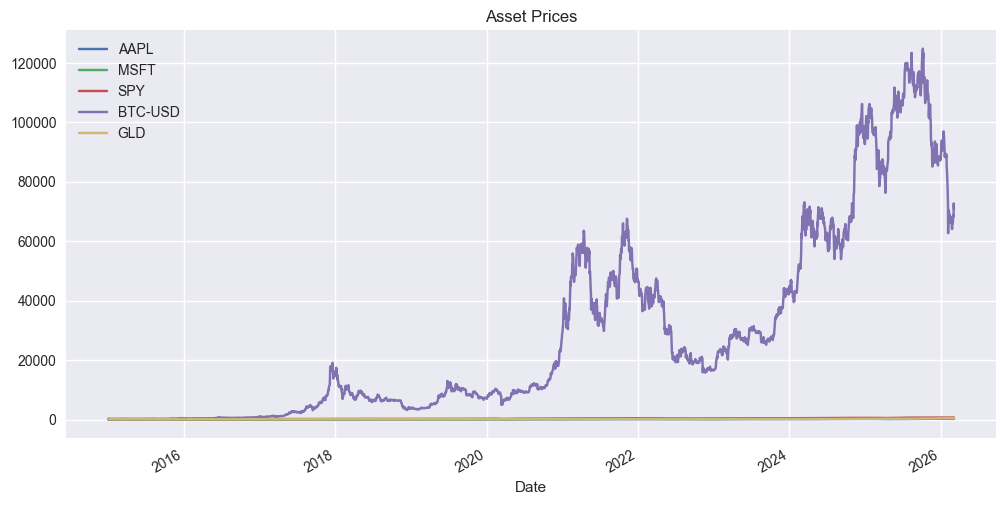

In [4]:
prices.plot(figsize=(12,6))
plt.title("Asset Prices")
plt.show()

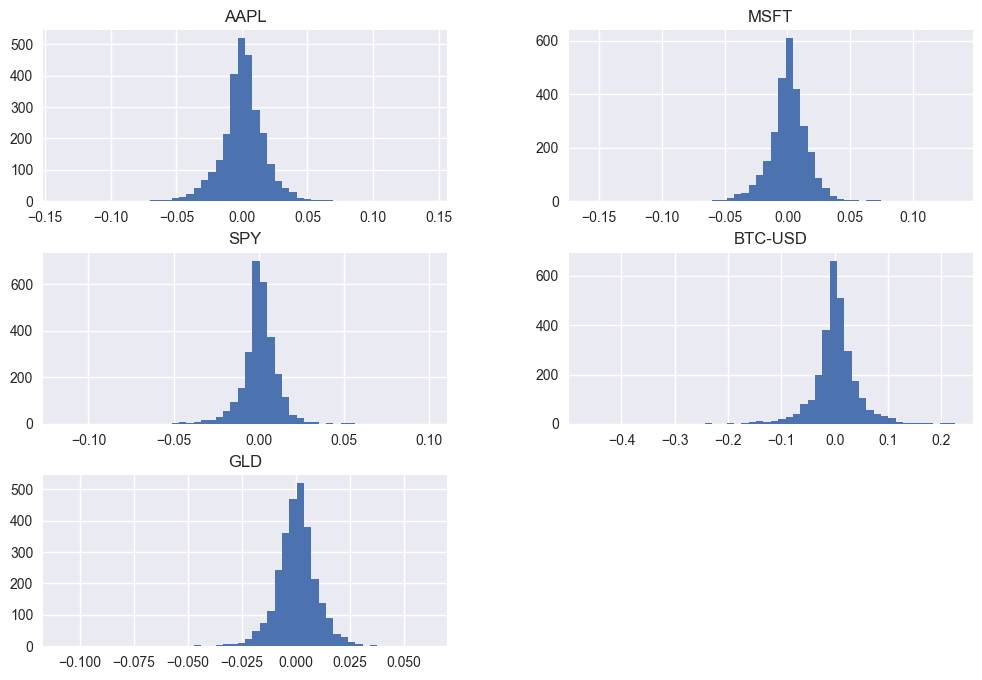

In [5]:
returns.hist(figsize=(12,8), bins=50)
plt.show()